## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_dark"
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Reading CSV

In [ ]:
df = pd.read_csv('/content/sample_data/zomato.csv', engine='python', on_bad_lines='skip')
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
df.shape

(51155, 17)

In [ ]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [ ]:
df = df.drop(['url', 'address', 'phone', 'menu_item', 'dish_liked', 'reviews_list'], axis = 1)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51155 entries, 0 to 51154
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         51155 non-null  object
 1   online_order                 51155 non-null  object
 2   book_table                   51155 non-null  object
 3   rate                         43380 non-null  object
 4   votes                        51155 non-null  int64 
 5   location                     51134 non-null  object
 6   rest_type                    50931 non-null  object
 7   cuisines                     51110 non-null  object
 8   approx_cost(for two people)  50811 non-null  object
 9   listed_in(type)              51155 non-null  object
 10  listed_in(city)              51155 non-null  object
dtypes: int64(1), object(10)
memory usage: 4.3+ MB


## Dropping Duplicates

In [ ]:
df.drop_duplicates(inplace = True)
df.shape

(51049, 11)

##Cleaning Rate Column

In [ ]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', nan, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '2.4 /5', '4.7 /5',
       '2.2 /5', '2.0 /5', '2.1 /5', '1.8 /5'], dtype=object)

##Removing "NEW" , "-" and "/5" from Rate Column

In [ ]:
def handlerate(value):
    if(value=='NEW' or value=='-'):
        return np.nan
    else:
        value = str(value).split('/')
        value = value[0]
        return float(value)

df['rate'] = df['rate'].apply(handlerate)
df['rate'].head()

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


##Filling Null Values in Rate Column with Mean

In [ ]:
df['rate'].fillna(df['rate'].mean(), inplace = True)
df['rate'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51049 entries, 0 to 51154
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         51049 non-null  object 
 1   online_order                 51049 non-null  object 
 2   book_table                   51049 non-null  object 
 3   rate                         51049 non-null  float64
 4   votes                        51049 non-null  int64  
 5   location                     51028 non-null  object 
 6   rest_type                    50825 non-null  object 
 7   cuisines                     51004 non-null  object 
 8   approx_cost(for two people)  50707 non-null  object 
 9   listed_in(type)              51049 non-null  object 
 10  listed_in(city)              51049 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.7+ MB


##Dropping Null Values

In [ ]:
df.dropna(inplace = True)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [ ]:
df.rename(columns = {'approx_cost(for two people)':'Cost2plates', 'listed_in(type)':'Type'}, inplace = True)
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,Type,listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [ ]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Sarjapur Road', 'Whitefield', 'East Bangalore',
       'Old Airport Road', 'Indiranagar', 'Koramangala 1st Block',
       'Frazer Town', 'RT Nagar', 'MG Road', 'Brigade Road',
       'Lavelle Road', 'Church Street', 'Ulsoor', 'Residency Road',
       'Shivajinagar', 'Infantry Road', 'St. Marks Road',
       'Cunningham Road', 'Race Course Road', 'Commercial Street',
       'Vasanth Nagar', 'HBR Layout', 'Domlur', 'Ejipura',
       'Jeeva

In [ ]:
df['listed_in(city)'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

##Listed in(city) and location, both are there, lets keep only one.

In [ ]:
df = df.drop(['listed_in(city)'], axis = 1)

In [ ]:
df['Cost2plates'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '80', '1,100', '160',
       '1,600', '230', '130', '50', '190', '1,700', '1,400', '180',
       '1,350', '2,200', '2,000', '1,800', '1,900', '330', '2,500',
       '2,100', '3,000', '2,800', '3,400', '40', '1,250', '3,500',
       '4,000', '2,400', '2,600', '120', '1,450', '469', '70', '3,200',
       '60', '560', '240', '360', '6,000', '1,050', '2,300', '4,100',
       '5,000', '3,700', '1,650', '2,700', '4,500', '140'], dtype=object)

##Removing , from Cost2Plates Column

In [ ]:
def handlecomma(value):
    value = str(value)
    if ',' in value:
        value = value.replace(',', '')
        return float(value)
    else:
        return float(value)

df['Cost2plates'] = df['Cost2plates'].apply(handlecomma)
df['Cost2plates'].unique()

array([ 800.,  300.,  600.,  700.,  550.,  500.,  450.,  650.,  400.,
        900.,  200.,  750.,  150.,  850.,  100., 1200.,  350.,  250.,
        950., 1000., 1500., 1300.,  199.,   80., 1100.,  160., 1600.,
        230.,  130.,   50.,  190., 1700., 1400.,  180., 1350., 2200.,
       2000., 1800., 1900.,  330., 2500., 2100., 3000., 2800., 3400.,
         40., 1250., 3500., 4000., 2400., 2600.,  120., 1450.,  469.,
         70., 3200.,   60.,  560.,  240.,  360., 6000., 1050., 2300.,
       4100., 5000., 3700., 1650., 2700., 4500.,  140.])

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0,Buffet


##Cleaning Rest Type Column

In [ ]:
rest_types = df['rest_type'].value_counts(ascending  = False)
rest_types

,count
rest_type,
Quick Bites,18979
Casual Dining,10135
Cafe,3621
Delivery,2563
Dessert Parlor,2232
...,...
"Dessert Parlor, Kiosk",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


In [ ]:
rest_types_lessthan1000 = rest_types[rest_types<1000]
rest_types_lessthan1000

,count
rest_type,
Beverage Shop,863
Bar,668
Food Court,616
Sweet Shop,468
"Bar, Casual Dining",388
...,...
"Dessert Parlor, Kiosk",2
"Dessert Parlor, Food Court",2
"Food Court, Beverage Shop",2


##Making Rest Types less than 1000 in frequency as others

In [ ]:
def handle_rest_type(value):
    if(value in rest_types_lessthan1000):
        return 'others'
    else:
        return value

df['rest_type'] = df['rest_type'].apply(handle_rest_type)
df['rest_type'].value_counts()

,count
rest_type,
Quick Bites,18979
Casual Dining,10135
others,8737
Cafe,3621
Delivery,2563
Dessert Parlor,2232
"Takeaway, Delivery",2005
Bakery,1139
"Casual Dining, Bar",1076


##Cleaning Location Column

In [ ]:
location = df['location'].value_counts(ascending  = False)

location_lessthan300 = location[location < 300]

df['location'] = df['location'].apply(
    lambda x: 'others' if x in location_lessthan300 else x
)

##Cleaning Cuisines Column

In [ ]:
cuisines = df['cuisines'].value_counts(ascending  = False)


cuisines_lessthan100 = cuisines[cuisines<100]



def handle_cuisines(value):
    if(value in cuisines_lessthan100):
        return 'others'
    else:
        return value

df['cuisines'] = df['cuisines'].apply(handle_cuisines)
df['cuisines'].value_counts()

,count
cuisines,
others,25883
North Indian,2829
"North Indian, Chinese",2337
South Indian,1817
Biryani,902
...,...
"Chinese, Thai, Momos",111
"Cafe, Bakery",109
"South Indian, Chinese, North Indian",105


In [ ]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,others,800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,others,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,others,800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,others,600.0,Buffet


##Data Cleaning Done!, Lets jump to Visualization.

## Count Plot of Various Locations

In [ ]:

fig = px.histogram(df, y='location', color='online_order', orientation='h',

    labels={
        'location': 'Restaurant Location',
        'online_order': 'Online Order Available'
    },

    color_discrete_map={'Yes': '#00CC96','No': '#EF553B'},

    title='Online Order Availability by Location'
)

fig.update_layout(
    barmode='stack',
    font=dict(family='Montserrat'),

    xaxis_title='Restaurant Count',
    yaxis_title='Location'
)

fig.show()

## Visualizing Online Order

In [ ]:
fig = px.histogram( df, y='online_order', orientation='h', color='online_order',
    color_discrete_sequence=['#19D3F3', '#636EFA'])

fig.update_layout(font=dict(family='Montserrat'),

    title='Online Order Count',
    legend_title='Online Order',

    yaxis_title='Online Order',
    xaxis_title='Count',

)

fig.show()

## Visualizing Book Table

In [ ]:
fig = px.histogram( df,y='book_table', color='book_table',
                   color_discrete_map={ 'Yes': '#00E5FF', 'No': '#FFA15A'}
                    )

fig.update_layout( font=dict( family='Montserrat'),

    title='Table Booking Availability',
    legend_title='Book Table',

    xaxis_title='Count',
    yaxis_title='Book Table'
)

fig.show()

## Visualizing Online Order vs Rate

In [ ]:
fig = px.box( df, x='online_order', y='rate', color='online_order',

    color_discrete_map={ 'Yes': '#00E5FF', 'No': '#FFA15A'}
)

fig.update_layout(font=dict(family='Montserrat'),

    title='Ratings vs Online Order',
    legend_title='Online Order',

    xaxis_title='Online Order',
    yaxis_title='Rating'
)

fig.show()

## Visualizing Book Table vs Rate

In [ ]:
fig = px.box( df, x='book_table', y='rate', color='book_table',

    color_discrete_map={'Yes': '#00E5FF', 'No': '#FFA15A'})

fig.update_layout(font=dict(family='Montserrat'),

    title='Ratings vs Table Booking',
    legend_title='Book Table',

    xaxis_title='Book Table',
    yaxis_title='Rating'
)

fig.show()

## Visualizing Online Order Facility, Location Wise

In [ ]:
df1 = df.groupby(['location','online_order'])['name'].count()
df1.to_csv('location_online.csv')
df1 = pd.read_csv('location_online.csv')
df1 = pd.pivot_table(df1, values=None, index=['location'], columns=['online_order'], fill_value=0, aggfunc=np.sum)
df1

name      
online_order             No   Yes
location                         
BTM                    1760  3287
Banashankari            397   505
Banaswadi               302   338
Bannerghatta Road       684   918
Basavanagudi            243   439
Bellandur               512   751
Brigade Road            537   655
Brookefield             238   417
Church Street           197   327
Commercial Street       228   142
Cunningham Road         168   307
Domlur                  247   233
Ejipura                 214   218
Electronic City         676   569
Frazer Town             284   424
HSR                     584  1894
Indiranagar             688  1296
JP Nagar                904  1304
Jayanagar               549  1360
Kalyan Nagar            349   488
Kammanahalli            263   375
Koramangala 1st Block   383   841
Koramangala 4th Block   433   557
Koramangala 5th Block   819  1564
Koramangala 6th Block   443   674
Koramangala 7th Block   385   777
Lavelle Road            309   194
MG Road                 502   354
Malleshwaram            303   409
Marathahalli            689  1088
New BEL Road            253   383
Old Airport Road        216   216
Rajajinagar             284   298
Residency Road          416   247
Richmond Road           548   242
Sarjapur Road           317   711
Shanti Nagar            286   219
Shivajinagar            346   144
St. Marks Road          168   164
Ulsoor                  386   614
Whitefield              979  1109
others                 2060  2886

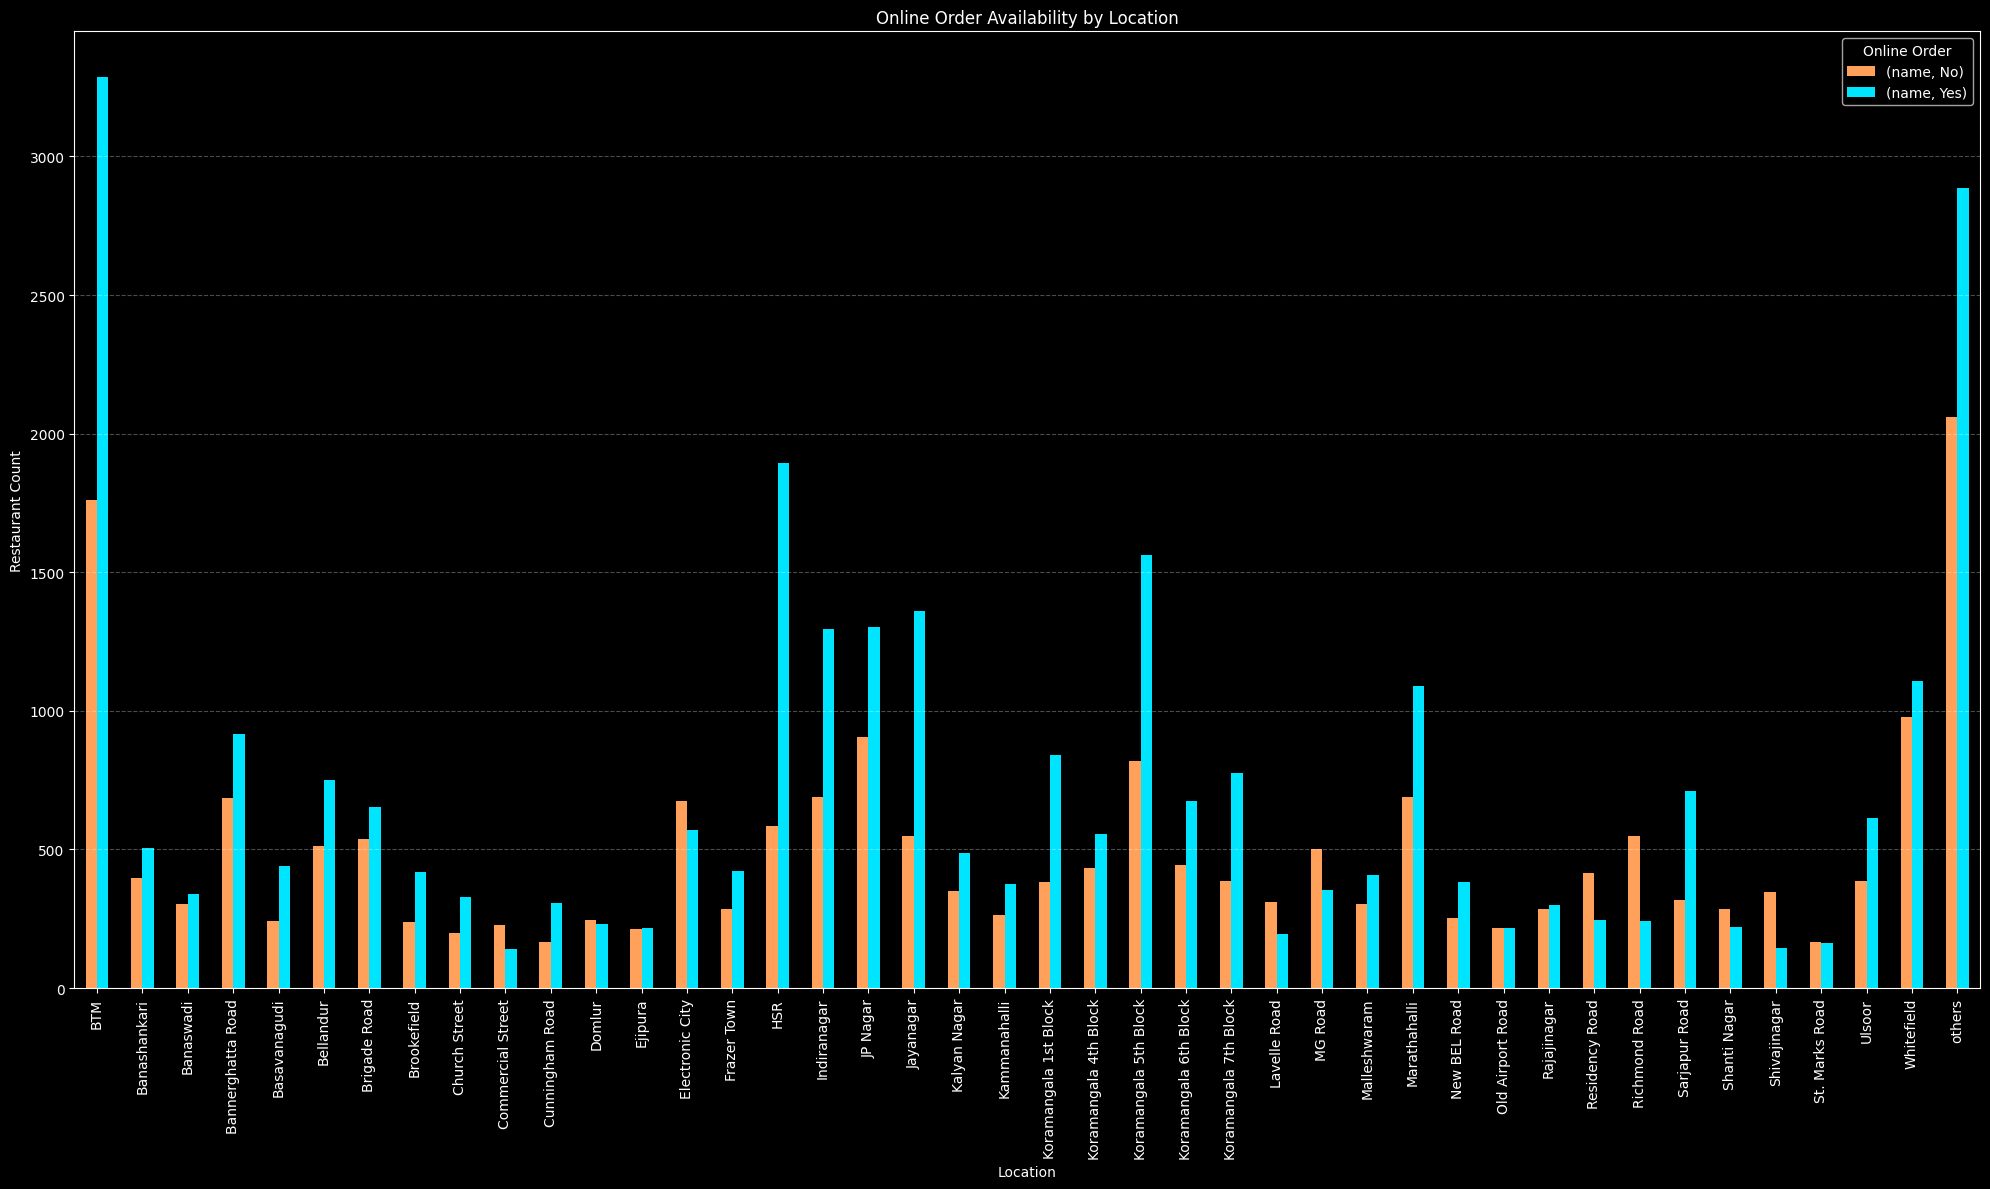

In [ ]:
plt.style.use('dark_background')

ax = df1.plot(
    kind='bar',
    figsize=(20,12),
    color=['#FFA15A', '#00E5FF']
)

plt.title('Online Order Availability by Location')

plt.xlabel('Location')

plt.ylabel('Restaurant Count')

plt.xticks(rotation=90)

plt.legend(title='Online Order')

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

##Visualizing Book Table Facility, Location Wise

In [ ]:
df2 = df.groupby(['location','book_table'])['name'].count()
df2.to_csv('location_booktable.csv')
df2 = pd.read_csv('location_booktable.csv')
df2 = pd.pivot_table(df2, values=None, index=['location'], columns=['book_table'], fill_value=0, aggfunc=np.sum)
df2

name     
book_table               No  Yes
location                        
BTM                    4880  167
Banashankari            839   63
Banaswadi               632    8
Bannerghatta Road      1509   93
Basavanagudi            666   16
Bellandur              1165   98
Brigade Road           1033  159
Brookefield             581   74
Church Street           355  169
Commercial Street       370    0
Cunningham Road         315  160
Domlur                  425   55
Ejipura                 432    0
Electronic City        1148   97
Frazer Town             701    7
HSR                    2268  210
Indiranagar            1548  436
JP Nagar               1897  311
Jayanagar              1632  277
Kalyan Nagar            691  146
Kammanahalli            589   49
Koramangala 1st Block  1175   49
Koramangala 4th Block   677  313
Koramangala 5th Block  1760  623
Koramangala 6th Block  1008  109
Koramangala 7th Block  1004  158
Lavelle Road            282  221
MG Road                 539  317
Malleshwaram            630   82
Marathahalli           1634  143
New BEL Road            584   52
Old Airport Road        378   54
Rajajinagar             546   36
Residency Road          514  149
Richmond Road           678  112
Sarjapur Road           889  139
Shanti Nagar            451   54
Shivajinagar            467   23
St. Marks Road          218  114
Ulsoor                  824  176
Whitefield             1844  244
others                 4581  365

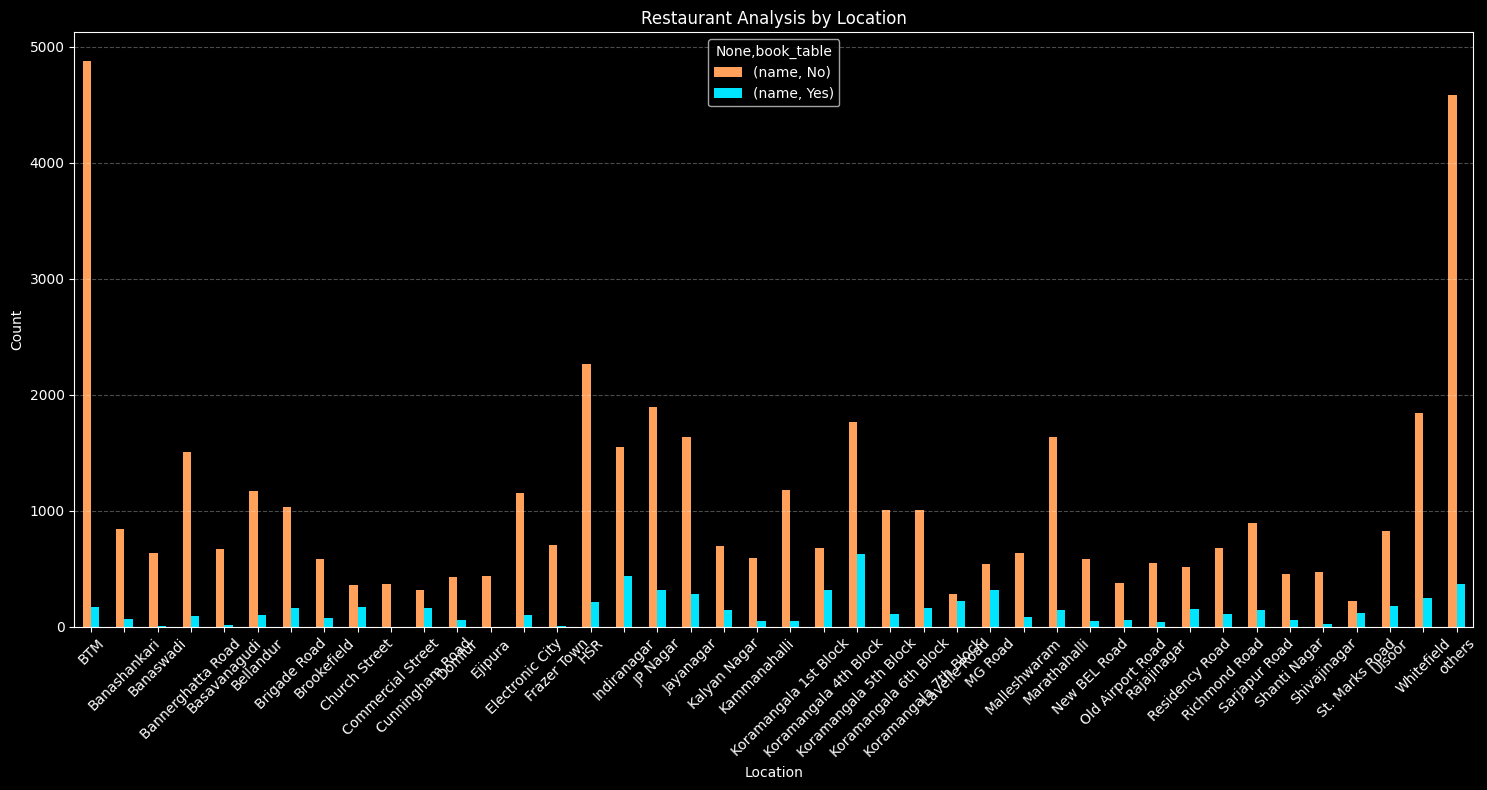

In [ ]:
plt.style.use('dark_background')

ax = df2.plot(
    kind='bar',
    figsize=(15,8),
    color=['#FFA15A', '#00E5FF']
)

plt.title('Restaurant Analysis by Location')
plt.xlabel('Location')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

##Visualizing Types of Restaurents vs Rate

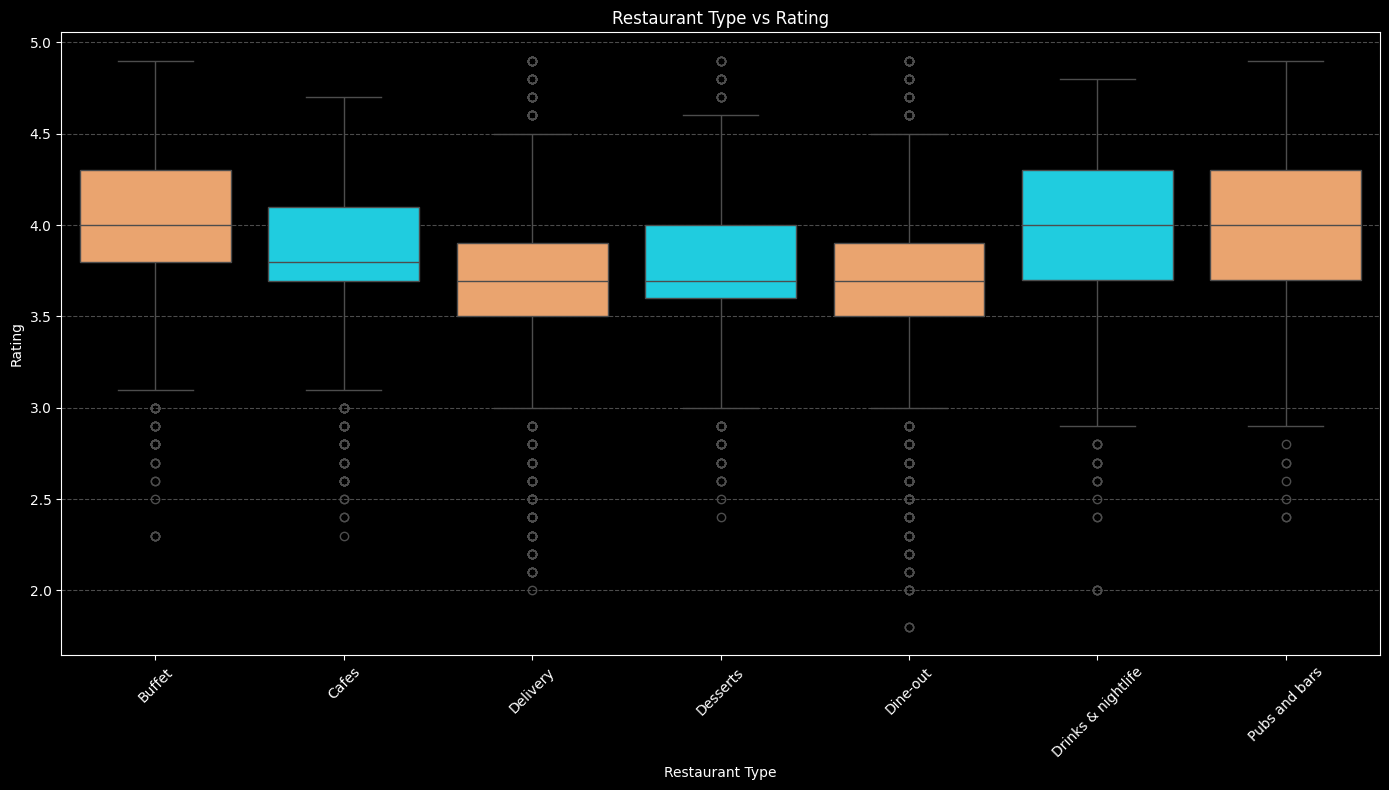

In [ ]:
plt.figure(figsize=(14,8))

sns.boxplot(
    x='Type',
    y='rate',
    data=df,
    palette=['#FFA15A', '#00E5FF']
)

plt.title('Restaurant Type vs Rating')

plt.xlabel('Restaurant Type')

plt.ylabel('Rating')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

##Grouping Types of Restaurents, location wise

In [ ]:
df3 = df.groupby(['location','Type'])['name'].count()
df3.to_csv('location_Type.csv')
df3 = pd.read_csv('location_Type.csv')
df3 = pd.pivot_table(df3, values=None, index=['location'], columns=['Type'], fill_value=0, aggfunc=np.sum)
df3

name                                   \
Type                  Buffet Cafes Delivery Desserts Dine-out   
location                                                        
BTM                       21    83     3047      198     1657   
Banashankari               7    36      418       71      356   
Banaswadi                  0    24      310       37      262   
Bannerghatta Road          9    46      824      137      576   
Basavanagudi               7    10      344       66      250   
Bellandur                 28    36      615       75      476   
Brigade Road              25    46      494      107      448   
Brookefield                6    17      338       45      245   
Church Street             16    45      184       28      194   
Commercial Street          0    13      121       77      159   
Cunningham Road           29    31      192       23      180   
Domlur                    15    13      259       35      135   
Ejipura                    0     0      245       16      171   
Electronic City           23    24      569       71      516   
Frazer Town                1    11      465       55      172   
HSR                       17    47     1687      120      575   
Indiranagar               36    94     1068      139      520   
JP Nagar                  44    76     1148      165      718   
Jayanagar                 27    77     1039      182      572   
Kalyan Nagar               9    45      366       88      311   
Kammanahalli               2    27      329       35      239   
Koramangala 1st Block      3    24      708       70      396   
Koramangala 4th Block     21    52      458       75      293   
Koramangala 5th Block     59   143     1051      204      804   
Koramangala 6th Block     18    43      507       68      407   
Koramangala 7th Block     25    52      502      127      414   
Lavelle Road              30    27      122       50      183   
MG Road                   51    70      260       68      327   
Malleshwaram              11    31      269       85      284   
Marathahalli              30    32      972      104      618   
New BEL Road               4    28      334       33      222   
Old Airport Road          10     5      200       35      163   
Rajajinagar               10     4      254       55      249   
Residency Road            20    31      187       62      285   
Richmond Road             61    18      253       78      352   
Sarjapur Road             22    22      553       82      312   
Shanti Nagar               9    22      198       39      227   
Shivajinagar               6    17      139       37      276   
St. Marks Road             5     9      110       10      139   
Ulsoor                    16    55      451       68      357   
Whitefield                28    51     1037      133      763   
others                    83   133     2783      276     1549   

                                                        
Type                  Drinks & nightlife Pubs and bars  
location                                                
BTM                                   22            19  
Banashankari                          14             0  
Banaswadi                              6             1  
Bannerghatta Road                      8             2  
Basavanagudi                           5             0  
Bellandur                             17            16  
Brigade Road                          50            22  
Brookefield                            4             0  
Church Street                         35            22  
Commercial Street                      0             0  
Cunningham Road                       14             6  
Domlur                                12            11  
Ejipura                                0             0  
Electronic City                       21            21  
Frazer Town                            2             2  
HSR                                   14            18  
Indiranagar    

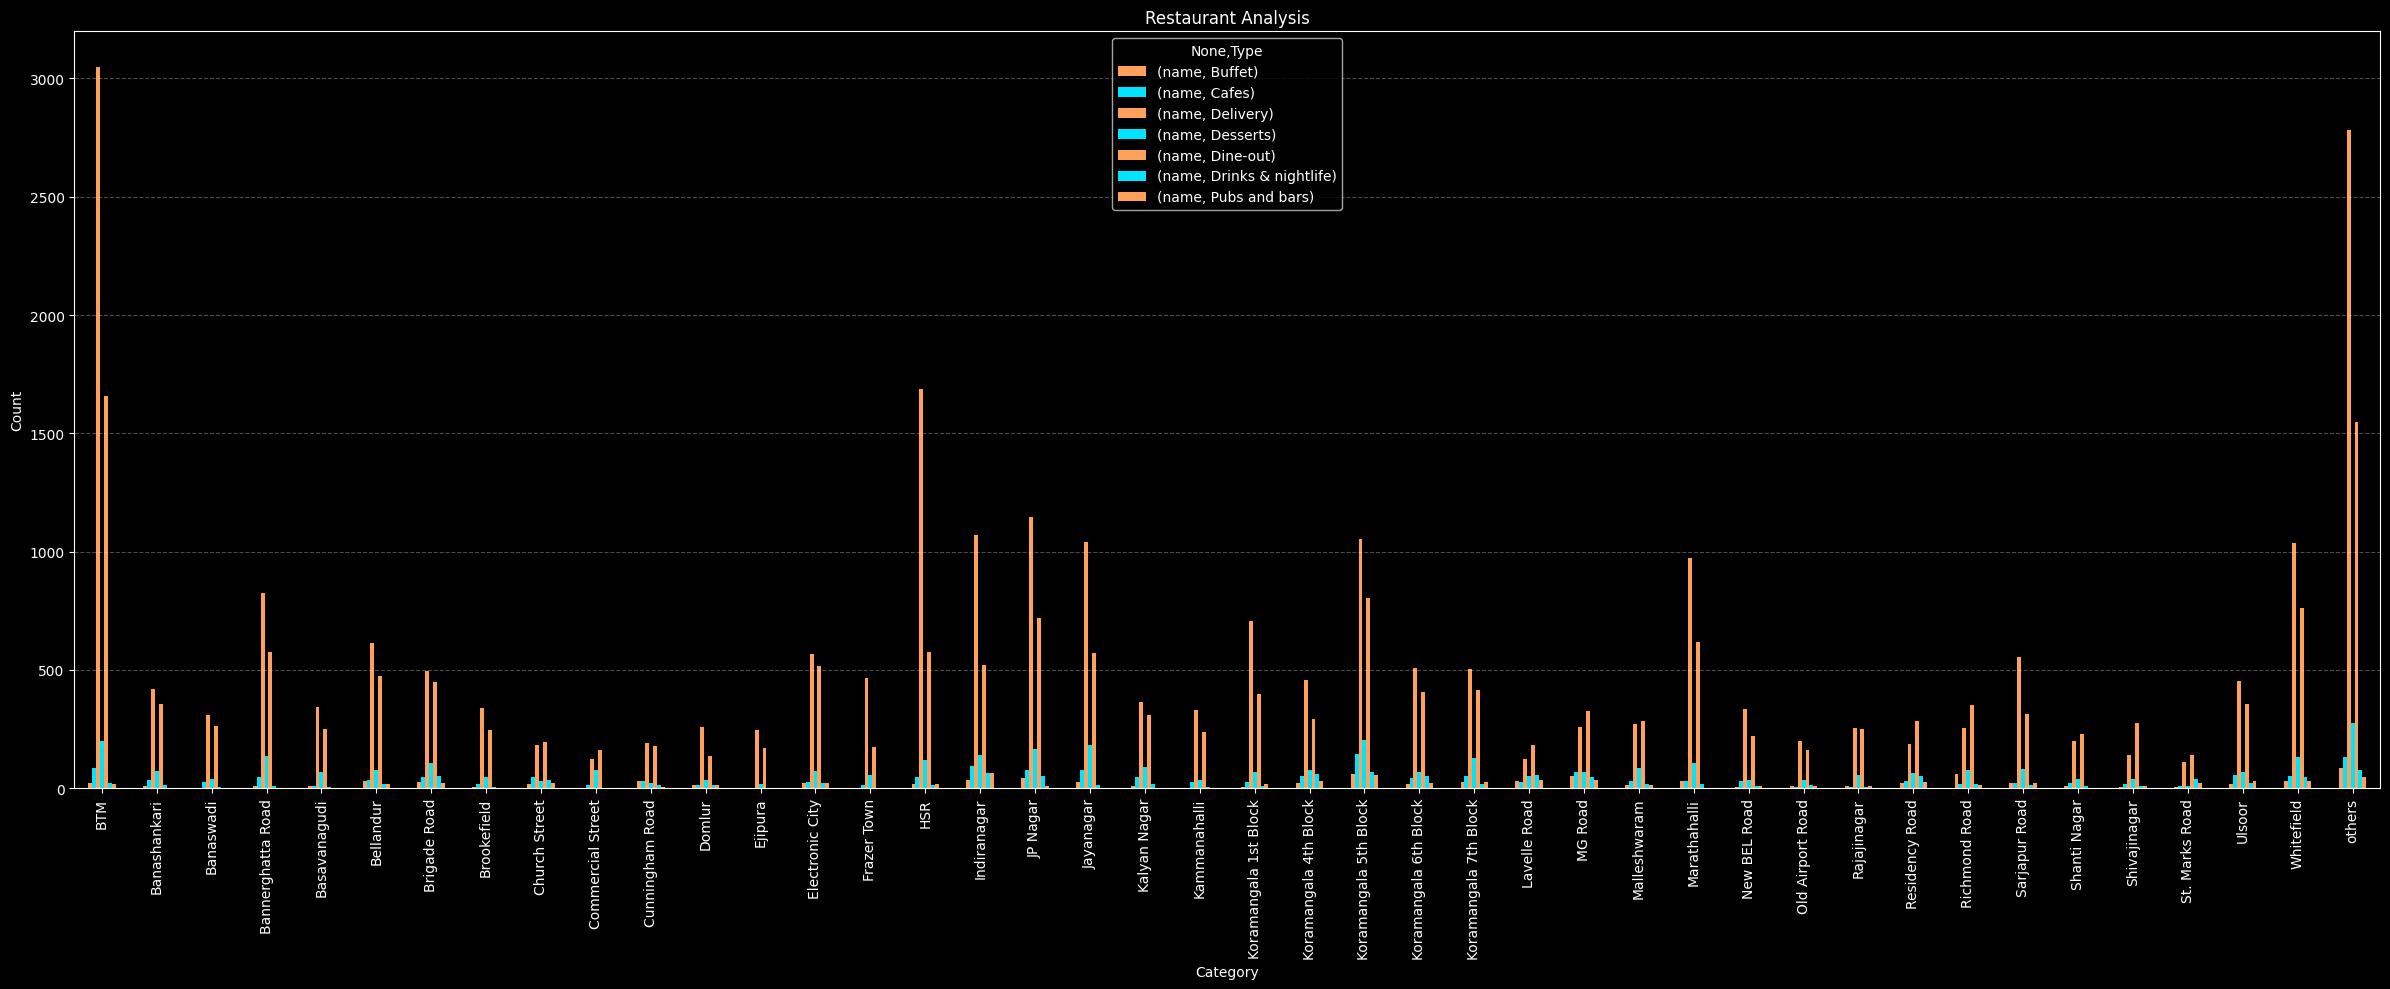

In [ ]:
plt.style.use('dark_background')

ax = df3.plot(
    kind='bar',
    figsize=(24,10),
    color=['#FFA15A', '#00E5FF']
)

plt.title('Restaurant Analysis')

plt.xlabel('Category')

plt.ylabel('Count')

plt.xticks(rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

##No. of Votes, Location Wise

In [ ]:
df4 = df[['location', 'votes']]
df4.drop_duplicates()
df5 = df4.groupby(['location'])['votes'].sum()
df5 = df5.to_frame()
df5 = df5.sort_values('votes', ascending=False)
df5.head()

,votes
location,
Koramangala 5th Block,1841713
Indiranagar,1086607
Koramangala 4th Block,604544
JP Nagar,580233
BTM,570824


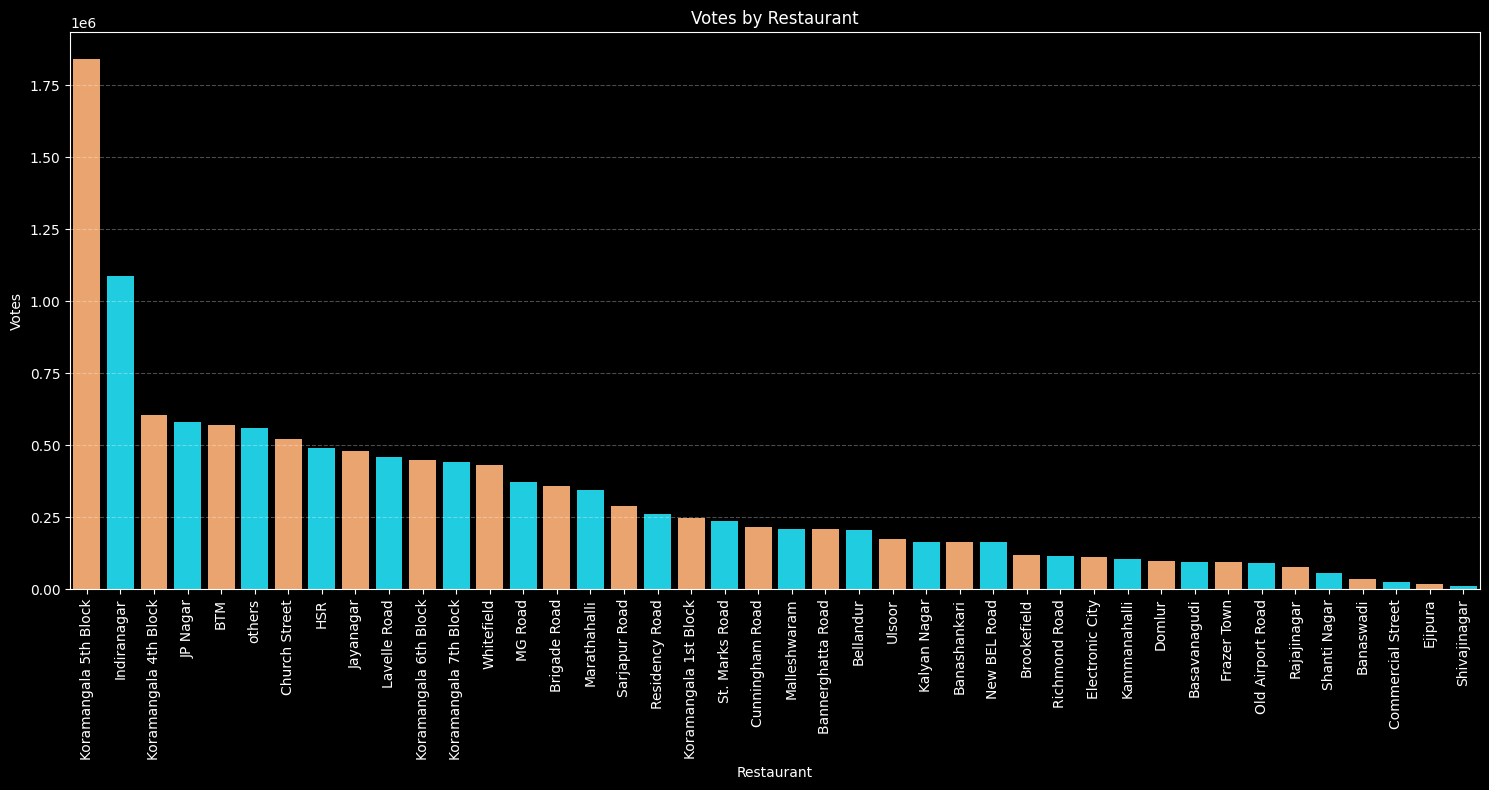

In [ ]:
plt.figure(figsize=(15,8))

sns.barplot(
    x=df5.index,
    y=df5['votes'],
    palette=['#FFA15A', '#00E5FF']
)

plt.title('Votes by Restaurant')

plt.xlabel('Restaurant')

plt.ylabel('Votes')

plt.xticks(rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,Cost2plates,Type
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,others,800.0,Buffet
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,others,800.0,Buffet
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,others,others,800.0,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0,Buffet
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,others,600.0,Buffet


##Visualizing Top Cuisines

In [ ]:
df6 = df[['cuisines', 'votes']]
df6.drop_duplicates()
df7 = df6.groupby(['cuisines'])['votes'].sum()
df7 = df7.to_frame()
df7 = df7.sort_values('votes', ascending=False)
df7.head()

,votes
cuisines,
others,10266520
North Indian,506442
"North Indian, Chinese",254149
South Indian,153031
Chinese,101728


In [ ]:
df7 = df7.iloc[1:, :]
df7.head()

,votes
cuisines,
North Indian,506442
"North Indian, Chinese",254149
South Indian,153031
Chinese,101728
"North Indian, Mughlai",98343


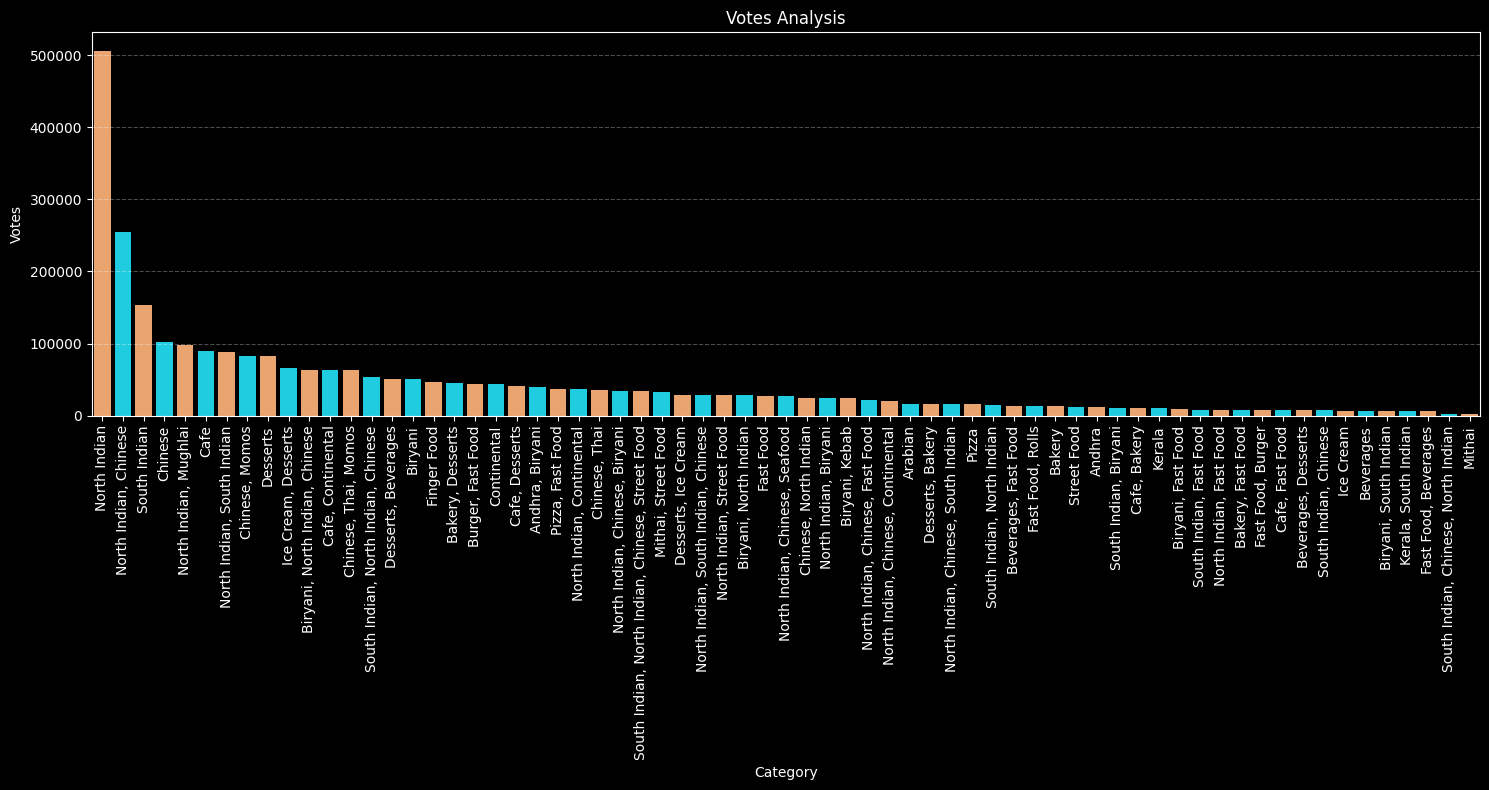

In [ ]:
plt.figure(figsize=(15,8))

sns.barplot(
    x=df7.index,
    y=df7['votes'],
    palette=['#FFA15A', '#00E5FF']
)

plt.title('Votes Analysis')

plt.xlabel('Category')

plt.ylabel('Votes')

plt.xticks(rotation=90)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()